In [1]:
import pandas as pd 
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# 네트워크 정보

In [2]:
unit_mob = 200

In [3]:
nodelist = pd.read_csv("data\\nodelist_connected.csv")
edgelist = pd.read_csv("data\\edgelist_symmetric.csv")

edgelist["mobility"] = edgelist["Max. Number of Routes"] * unit_mob
nodelist = nodelist.set_index("ID")

In [4]:
num_nodes = len(nodelist)
num_edges = len(edgelist)

global_pop = nodelist["Population"].sum()
global_mob = edgelist["mobility"].sum()

# 결과 로드

In [5]:
results = pd.read_csv("results\\test_random_2-results.csv")
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29700 entries, 0 to 29699
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Number of edge cuts                     29700 non-null  int64  
 1   Edge cut seed                           29700 non-null  int64  
 2   Total mobility cut                      29700 non-null  float64
 3   Largest connected component size        29700 non-null  int64  
 4   Largest connected component population  29700 non-null  float64
 5   Diameter                                29700 non-null  float64
 6   Average distance                        29700 non-null  float64
 7   Basic reproduction number               29700 non-null  float64
 8   Recovery time                           29700 non-null  float64
 9   Global effective reproduciton number    29700 non-null  float64
 10  Infection origin                        29700 non-null  in

In [6]:
np.sum(results["Solver message"] != "A termination event occurred.")

0

In [7]:
results["Relative largest connected component size"] = results["Largest connected component size"] / num_nodes
results["Largest connected component population fraction"] = results["Largest connected component population"] / global_pop

results["Fraction of edge cuts"] = results["Number of edge cuts"] / num_edges
results["Fraction of mobility cuts"] = results["Total mobility cut"] / global_mob

# 시각화

In [8]:
basic_rep = 2.0
r_time = 14.0

sample = results.loc[(results["Basic reproduction number"] == basic_rep) & (results["Recovery time"] == r_time)]

## 네트워크 측정량들

Text(0.5, 1.0, 'Fraction of mobility lost by edge cutting')

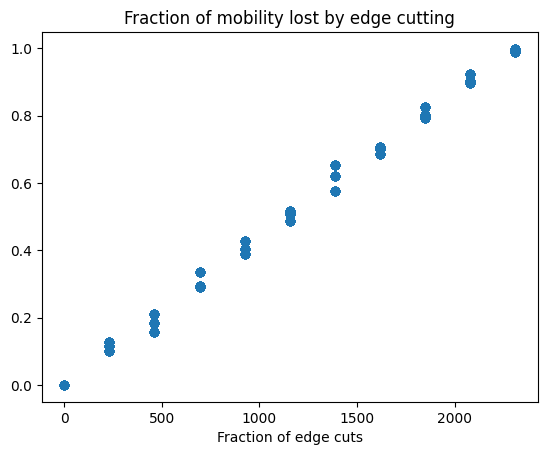

In [9]:
plt.scatter(sample["Number of edge cuts"], sample["Fraction of mobility cuts"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Fraction of mobility lost by edge cutting")

Text(0.5, 1.0, 'Fraction of nodes in largest connected component')

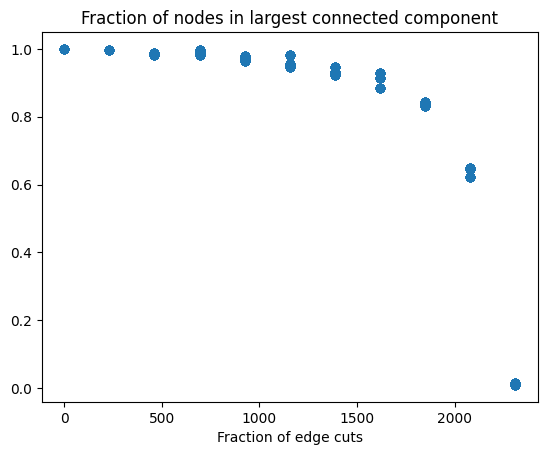

In [10]:
plt.scatter(sample["Number of edge cuts"], sample["Relative largest connected component size"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Fraction of nodes in largest connected component")

Text(0.5, 1.0, 'Fraction of population in largest connected component')

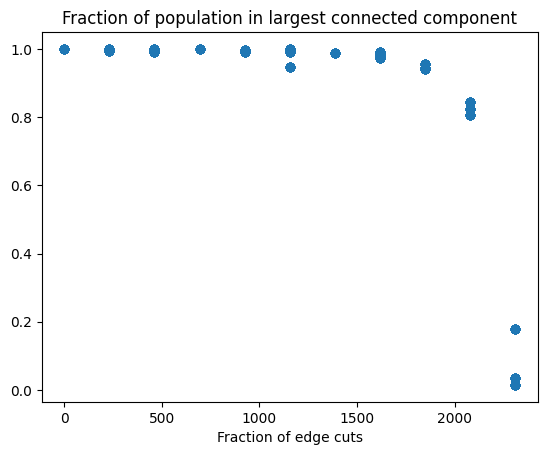

In [11]:
plt.scatter(sample["Number of edge cuts"], sample["Largest connected component population fraction"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Fraction of population in largest connected component")

Text(0.5, 1.0, 'Network diameter')

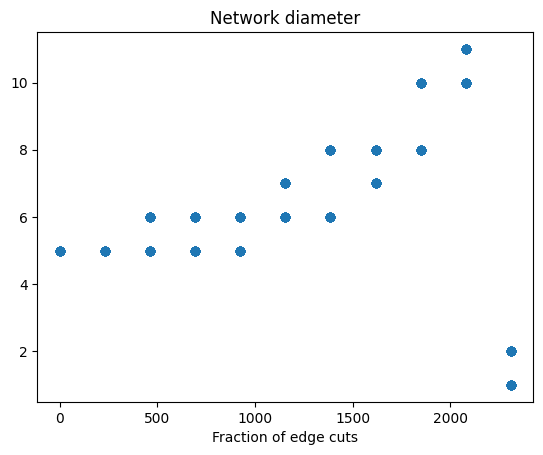

In [12]:
plt.scatter(sample["Number of edge cuts"], sample["Diameter"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Network diameter")

Text(0.5, 1.0, 'Average distance')

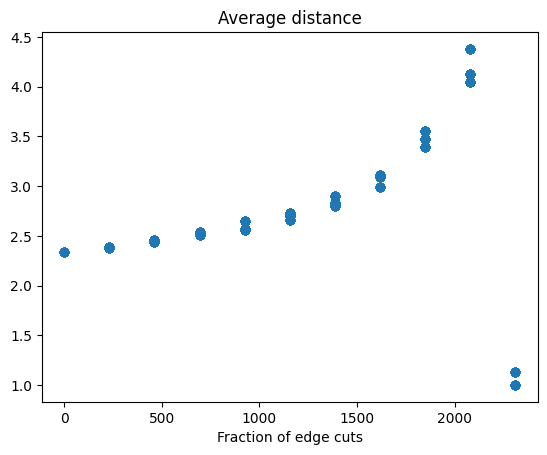

In [13]:
plt.scatter(sample["Number of edge cuts"], sample["Average distance"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Average distance")

## Global attack rate

Text(0.5, 1.0, 'Global attack rate vs. Fraction of edge cuts')

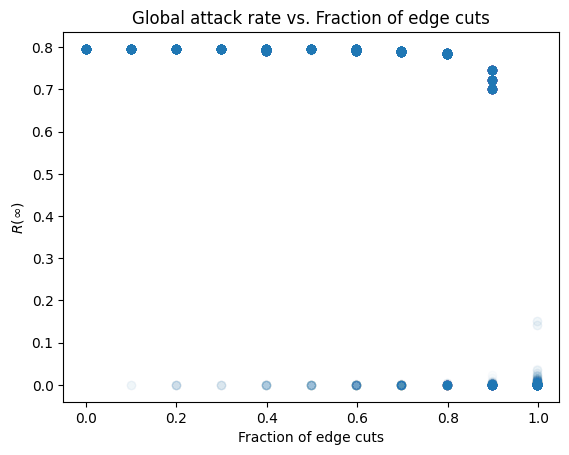

In [14]:
plt.scatter(sample["Fraction of edge cuts"], sample["Global attack rate"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$R(\infty)$")

plt.title(f"Global attack rate vs. Fraction of edge cuts")

Text(0.5, 1.0, 'Global attack rate vs. Fraction of mobility cuts')

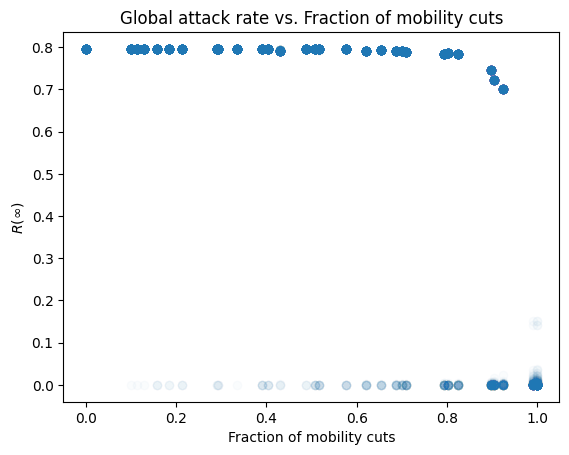

In [15]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Global attack rate"], alpha=0.02)

plt.xlabel("Fraction of mobility cuts")
plt.ylabel("$R(\infty)$")

plt.title(f"Global attack rate vs. Fraction of mobility cuts")

Text(0.5, 1.0, 'Global attack rate vs. Fraction of population in the LCC')

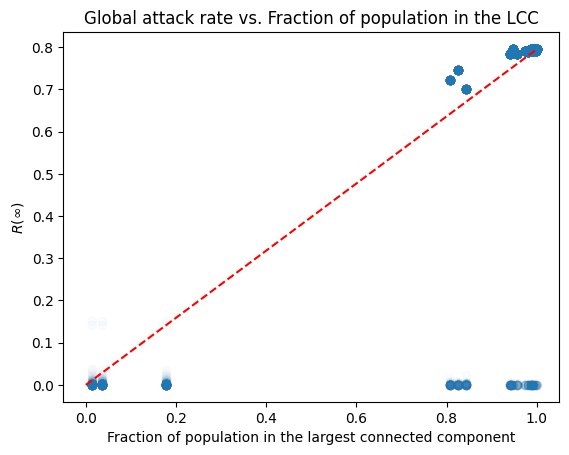

In [16]:
plt.scatter(sample["Largest connected component population fraction"], sample["Global attack rate"], alpha=0.02)
plt.plot([0, 1.0], [0.0, sample.loc[sample["Number of edge cuts"] == 0, "Global attack rate"].mean()], color='red', linestyle='--')

plt.xlabel("Fraction of population in the largest connected component")
plt.ylabel("$R(\infty)$")

plt.title(f"Global attack rate vs. Fraction of population in the LCC")

Text(0.5, 1.0, 'Global attack rate vs. Fraction of population in the LCC')

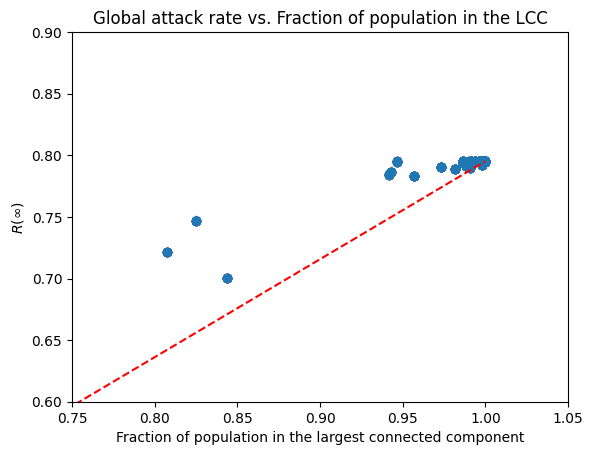

In [18]:
plt.scatter(sample["Largest connected component population fraction"], sample["Global attack rate"], alpha=0.02)
plt.plot([0, 1.0], [0.0, sample.loc[sample["Number of edge cuts"] == 0, "Global attack rate"].mean()], color='red', linestyle='--')

plt.xlim([0.75, 1.05])
plt.ylim([0.6, 0.9])

plt.xlabel("Fraction of population in the largest connected component")
plt.ylabel("$R(\infty)$")

plt.title(f"Global attack rate vs. Fraction of population in the LCC")

### 이상한 점

In [19]:
anomalies = results.loc[results["Largest connected component population fraction"] < results["Global attack rate"]]
len(anomalies)

2886

In [131]:
anomalies.head()

,Number of edge cuts,Edge cut seed,Total mobility cut,Largest connected component size,Largest connected component population,Diameter,Average distance,Basic reproduction number,Recovery time,Global effective reproduciton number,Infection origin,Solver message,Peak severity,Peak time,Global attack rate,Relative largest connected component size,Largest connected component population fraction,Fraction of edge cuts,Fraction of mobility cuts
27002,2310,0,3521000.0,2,10404292.5,1.0,1.0,2.0,14.0,2.0,11,A termination event occurred.,0.000567,214.990818,0.002943,0.008889,0.001415,0.996979,0.998469
27008,2310,0,3521000.0,2,10404292.5,1.0,1.0,2.0,14.0,2.0,16,A termination event occurred.,0.000897,221.438827,0.004661,0.008889,0.001415,0.996979,0.998469
27010,2310,0,3521000.0,2,10404292.5,1.0,1.0,2.0,14.0,2.0,18,A termination event occurred.,0.004168,244.551936,0.021677,0.008889,0.001415,0.996979,0.998469
27011,2310,0,3521000.0,2,10404292.5,1.0,1.0,2.0,14.0,2.0,4,A termination event occurred.,0.000818,220.333858,0.004247,0.008889,0.001415,0.996979,0.998469
27012,2310,0,3521000.0,2,10404292.5,1.0,1.0,2.0,14.0,2.0,20,A termination event occurred.,0.000492,213.321725,0.002556,0.008889,0.001415,0.996979,0.998469


## Peak time

Text(0.5, 1.0, 'Peak time vs. Fraction of edge cuts')

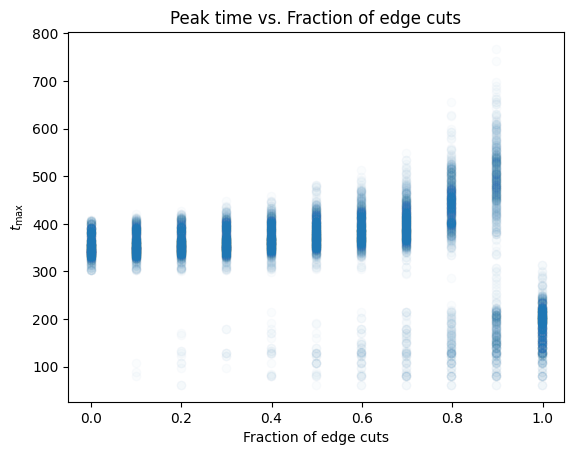

In [132]:
plt.scatter(sample["Fraction of edge cuts"], sample["Peak time"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Fraction of edge cuts")

Text(0.5, 1.0, 'Peak time vs. Fraction of mobility cuts')

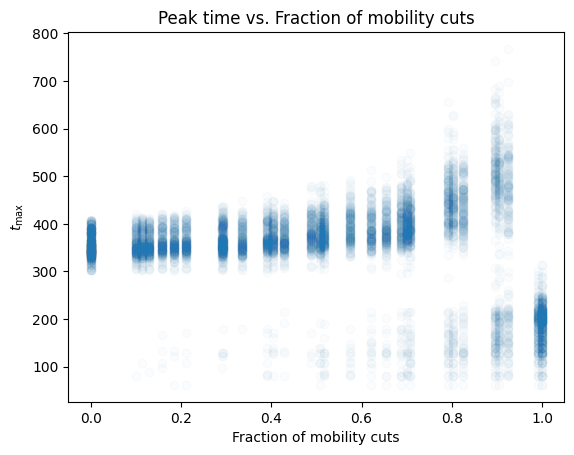

In [133]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Peak time"], alpha=0.02)

plt.xlabel("Fraction of mobility cuts")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Fraction of mobility cuts")

Text(0.5, 1.0, 'Peak time vs. Diameter')

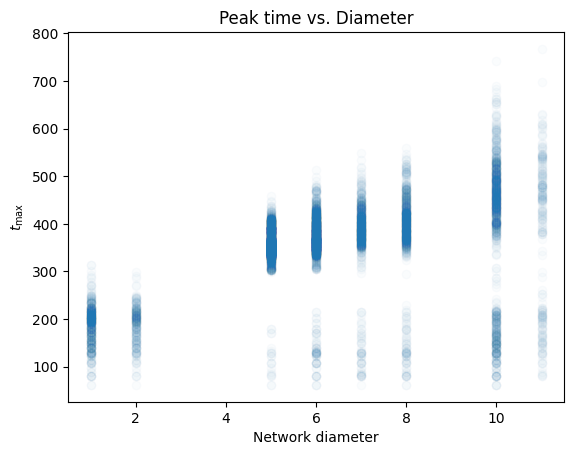

In [134]:
plt.scatter(sample["Diameter"], sample["Peak time"], alpha=0.02)

plt.xlabel("Network diameter")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Diameter")

Text(0.5, 1.0, 'Peak time vs. Average distance')

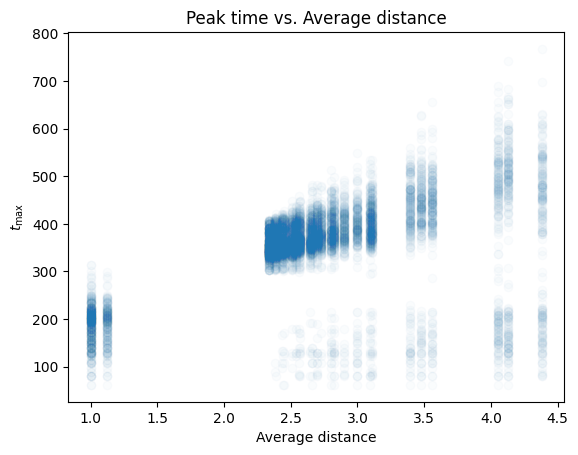

In [135]:
plt.scatter(sample["Average distance"], sample["Peak time"], alpha=0.02)

plt.xlabel("Average distance")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Average distance")

## Peak severity

Text(0.5, 1.0, 'Peak severity vs. Fraction of edge cuts')

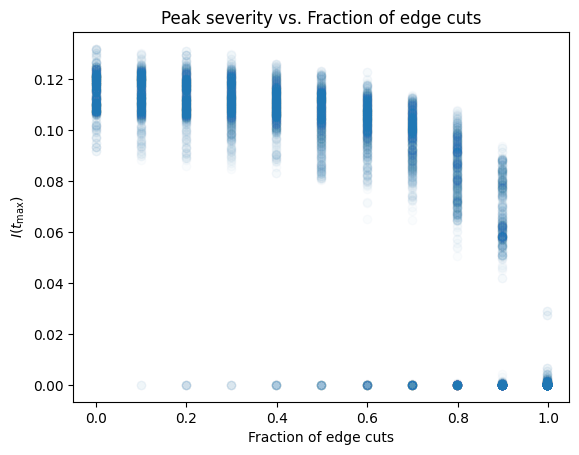

In [136]:
plt.scatter(sample["Fraction of edge cuts"], sample["Peak severity"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$I(t_\\text{max})$")

plt.title(f"Peak severity vs. Fraction of edge cuts")

Text(0.5, 1.0, 'Peak severity vs. Fraction of mobility cuts')

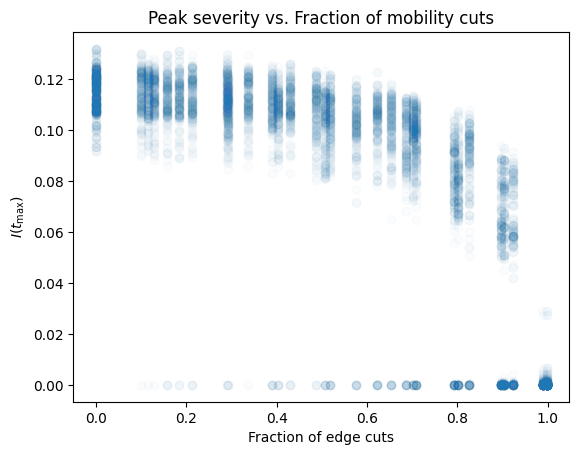

In [137]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Peak severity"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$I(t_\\text{max})$")

plt.title(f"Peak severity vs. Fraction of mobility cuts")

Text(0.5, 1.0, 'Peak severity vs. Fraction of population in the LCC')

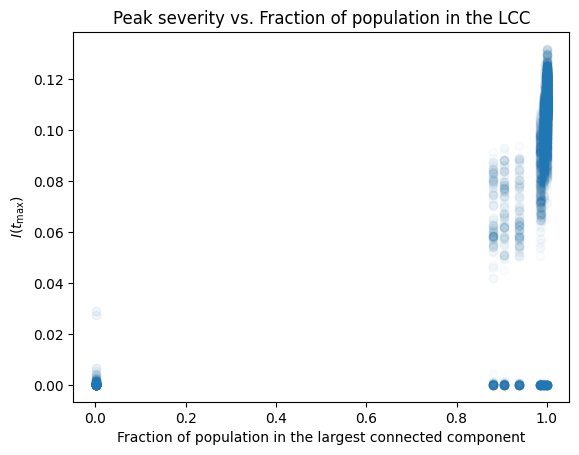

In [138]:
plt.scatter(sample["Largest connected component population fraction"], sample["Peak severity"], alpha=0.02)

plt.xlabel("Fraction of population in the largest connected component")
plt.ylabel("$I(t_\\text{max})$")

plt.title(f"Peak severity vs. Fraction of population in the LCC")

Text(0.5, 1.0, 'Peak severity vs. Fraction of population in the LCC')

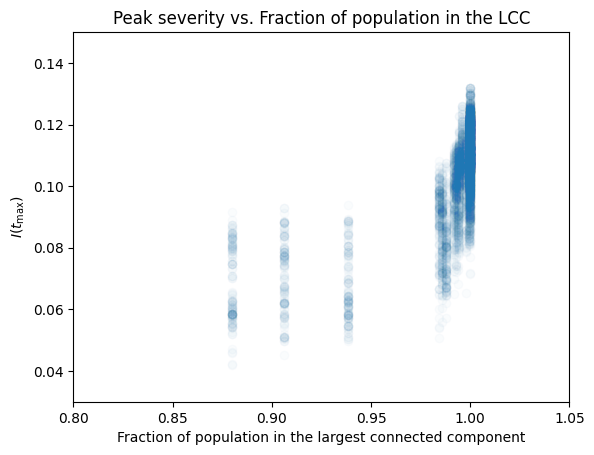

In [139]:
plt.scatter(sample["Largest connected component population fraction"], sample["Peak severity"], alpha=0.02)

plt.xlabel("Fraction of population in the largest connected component")
plt.ylabel("$I(t_\\text{max})$")

plt.xlim([0.8, 1.05])
plt.ylim([0.03, 0.15])

plt.title(f"Peak severity vs. Fraction of population in the LCC")

## Global effective reproduction number

Text(0.5, 1.0, 'Effective reproduction number vs. Fraction of edge cuts')

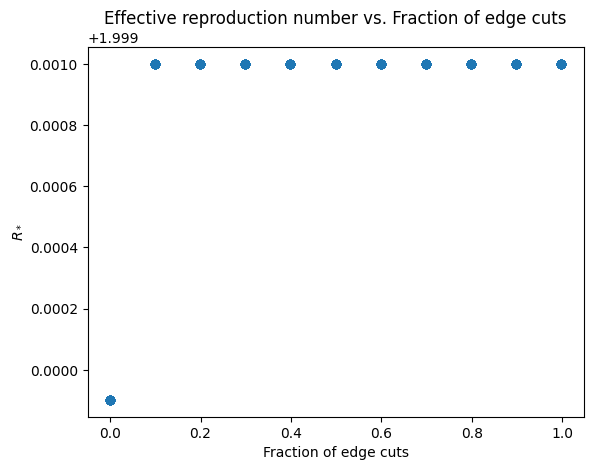

In [140]:
plt.scatter(sample["Fraction of edge cuts"], sample["Global effective reproduciton number"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$R_*$")

plt.title(f"Effective reproduction number vs. Fraction of edge cuts")

Text(0.5, 1.0, 'Effective reproduction number vs. Fraction of mobility cuts')

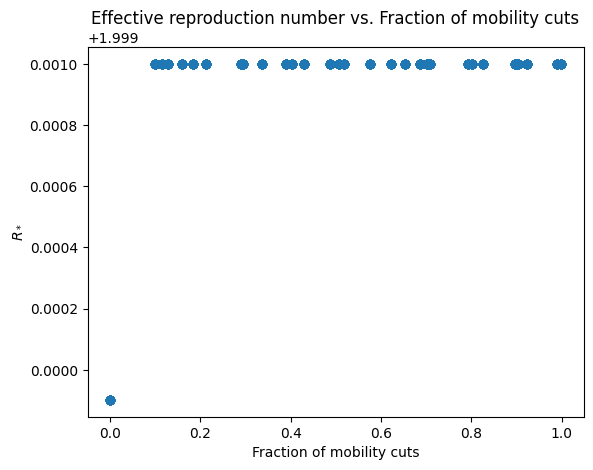

In [141]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Global effective reproduciton number"], alpha=0.02)

plt.xlabel("Fraction of mobility cuts")
plt.ylabel("$R_*$")

plt.title(f"Effective reproduction number vs. Fraction of mobility cuts")